
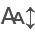

In [25]:
import torch
import torch.optim as optim
from torchviz import make_dot
import pandas as pd
from itables import init_notebook_mode, show
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import importlib
from tqdm import tqdm
from torchvision import transforms

import gradual_aacbr
import semantics.mlp_semantics as ms
import semantics.relu_semantics as rs
import base_scores.feature_weighted_base_score as fwbs
import casebase_edge_weights.feature_weighted_partial_order as fwpo
import casebase_edge_weights.learned_partial_order as lpo
import irrelevance_edge_weights.feature_weighted_irrelevance as fwi
import irrelevance_edge_weights.regular_irrelevance as ri

init_notebook_mode(all_interactive=True)

In [26]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(ms)
    importlib.reload(rs)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(fwi)
    importlib.reload(ri)
    importlib.reload(lpo)

reload_imports()

## Gradual AACBR

tensor([[0.8406, 0.8417]], grad_fn=<IndexBackward0>)


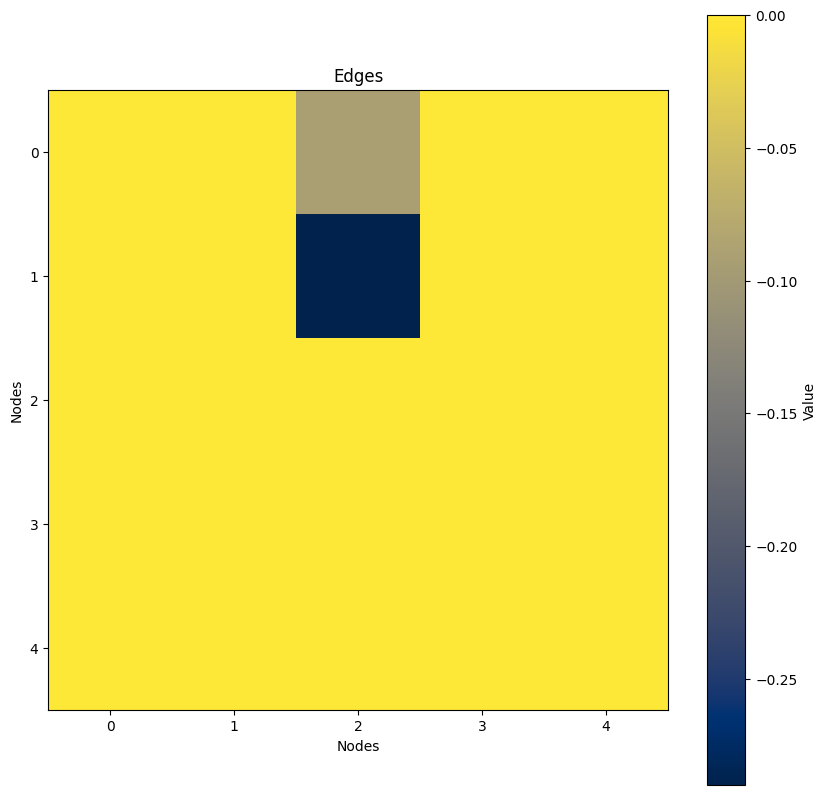

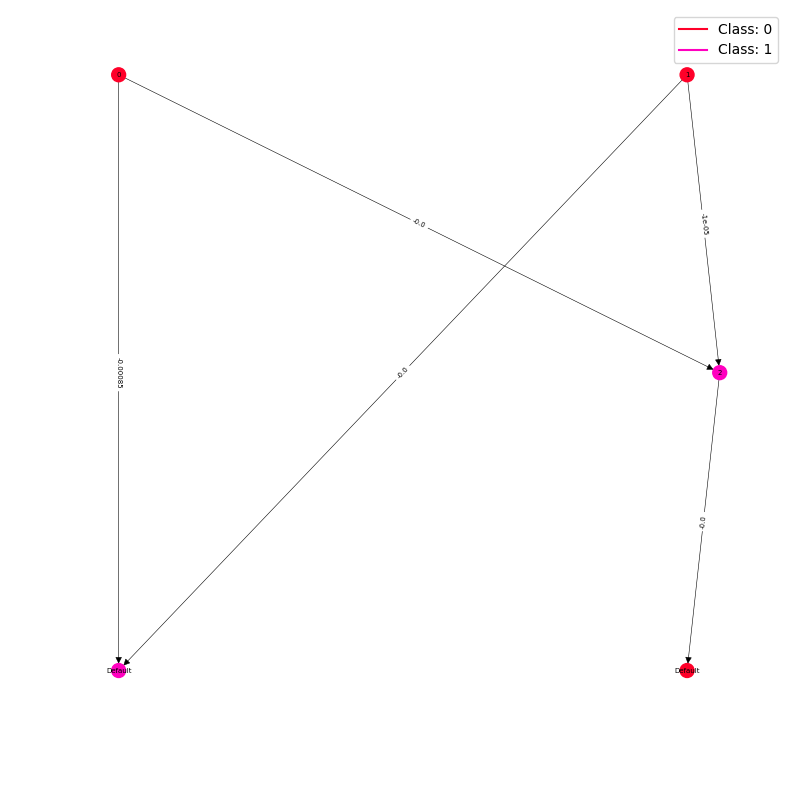

In [27]:
reload_imports()
X_train = torch.tensor([
    [1], # 0
    [3], # 1
    [5], # 1
], dtype=torch.float32)

y_train = torch.tensor([[1, 0], [1, 0], [0, 1]], dtype=torch.float32)

X_default = torch.tensor([
        [0], [0]
], dtype=torch.float32) # 2, 3
y_default = torch.tensor([[0, 1], [1, 0]], dtype=torch.float32)

torch.manual_seed(0)

no_features = X_train.shape[-1]
# semantics = ms.MLPBasedSemantics(max_iters=5, epsilon=0)
semantics = rs.ReluSemantics(max_iters=5, epsilon=0)
model = gradual_aacbr.GradualAACBR(semantics, 
                                   fwbs.FeatureWeightedBaseScore(no_features), 
                                   fwi.FeatureWeightedIrrelevance(no_features), 
                                   fwpo.FeatureWeightedPartialOrder(no_features, sharpness=0.5))

model.fit(X_train, y_train, X_default, y_default)

new_case = torch.tensor([
    [2],
], dtype=torch.float32)

strengths = model(new_case)
print(strengths)

model.show_matrix()
model.show_graph_with_labels()



## Data Set

In [28]:
SEED = 42

In [29]:
# MNIST
# from torchvision.datasets import MNIST
# mnist_trainset = MNIST("./temp/", train=True, download=True)
# mnist_testset = MNIST("./temp/", train=False, download=True)


# X = mnist_trainset.data[:1000].view(-1, 784).float()
# y = mnist_trainset.targets[:1000]
# print(X.shape)
# print(np.unique(y))

In [30]:
# # data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')
data = pd.read_csv('data/iris/iris.data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))




['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [31]:
y = y.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
# encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

show(y)
all_y = np.unique(y, axis=0)

## Train Model

### Split into Training, Validation and Test

In [32]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")

Test Size:  30
Train Size:  95
Validation Size:  24


### Cluster dataset

In [33]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# GROUP_PROPORTION = 0.25 
GROUP_PROPORTION = 0.5

# Example data
# X = np.random.randn(132, 2)


cluster_size_func = lambda total_size: 15

# cluster_size_func = lambda total_size: int(total_size * GROUP_PROPORTION)


X_all_centroids = []
y_all_centroids = []

for selected_y in all_y:


    group = X_train[np.all(selected_y == y_train, axis=1)]

    # Number of clusters
    k = cluster_size_func(len(group))

    print(f"{k} clusters for {selected_y}")

    # Create a KMeans object
    kmeans = KMeans(n_clusters=k, random_state=0)

    # Fit the model to the data and predict cluster assignments
    cluster_assignments = kmeans.fit_predict(group)

    # Get the centroids
    X_centroids_group = kmeans.cluster_centers_
    y_centroids_group = np.tile(selected_y, (k, 1))

    X_all_centroids.append(X_centroids_group)
    y_all_centroids.append(y_centroids_group)

X_centroids =  np.concatenate(X_all_centroids)
y_centroids =  np.concatenate(y_all_centroids)

15 clusters for [0. 0. 1.]
15 clusters for [0. 1. 0.]
15 clusters for [1. 0. 0.]


In [34]:
# X_train = X_centroids
# y_train = y_centroids
X_centroids = torch.tensor(X_centroids, dtype=torch.float32)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32)

### Convert to Torch

In [35]:
X_train_full, y_train_full = torch.tensor(X_train_full), torch.tensor(y_train_full, dtype=torch.float32)
X_train, y_train = torch.tensor(X_train), torch.tensor(y_train, dtype=torch.float32)
X_val, y_val = torch.tensor(X_val), torch.tensor(y_val, dtype=torch.float32)
X_test, y_test = torch.tensor(X_test), torch.tensor(y_test, dtype=torch.float32)

### Normalize dataset

In [36]:
# train_mean = X_train.mean(dim=0)
# train_std = X_train.std(dim=0)

# X_train = (X_train - train_mean)/train_std
# X_val = (X_val - train_mean)/train_std
# X_test = (X_test - train_mean)/train_std



In [37]:
print(X_train)

tensor([[6.1000, 2.9000, 4.7000, 1.4000],
        [6.3000, 2.3000, 4.4000, 1.3000],
        [5.8000, 2.7000, 3.9000, 1.2000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [7.7000, 3.8000, 6.7000, 2.2000],
        [5.8000, 2.7000, 5.1000, 1.9000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.8000, 2.7000, 4.1000, 1.0000],
        [5.7000, 3.0000, 4.2000, 1.2000],
        [5.0000, 3.2000, 1.2000, 0.2000],
        [6.4000, 3.2000, 4.5000, 1.5000],
        [6.3000, 2.7000, 4.9000, 1.8000],
        [6.1000, 2.6000, 5.6000, 1.4000],
        [6.1000, 2.8000, 4.7000, 1.2000],
        [5.5000, 4.2000, 1.4000, 0.2000],
        [4.8000, 3.4000, 1.9000, 0.2000],
        [6.3000, 2.5000, 4.9000, 1.5000],
        [6.1000, 3.0000, 4.9000, 1.8000],
        [4.8000, 3.0000, 1.4000, 0.3000],
        [6.5000, 2.8000, 4.6000, 1.5000],
        [6.5000, 3.0000, 5.5000, 1.8000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [6.0000, 2.2000, 5.0000, 1

### Build AF

In [38]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 2 

def binarise_by_normal(case):
    # return np.where(np.abs(case - means) <= STD_PARAM*std, 0, 1)
    return torch.where(torch.abs(case - means) <= STD_PARAM*std, 0, 1).to(torch.float32)


def to_stds(case):
    z_scores = (case - means)/std
    thresholds = torch.tensor([2.5, 1.5, 0.5, -0.5, -1.5, -2.5]).unsqueeze(0)
    discretized = torch.sum(z_scores.unsqueeze(2) > thresholds, dim=2) - 3
    return discretized.to(torch.float32)

 
    

In [39]:
# PREPROCESS_FUNC = to_stds 
# PREPROCESS_FUNC = binarise_by_normal 
PREPROCESS_FUNC = lambda x: x

### Train Model

In [40]:
DEFAULT_CASE = means
# DEFAULT_CASE = torch.zeros_like(means)

X_DEFAULTS = PREPROCESS_FUNC(DEFAULT_CASE.tile(len(all_y), 1))
Y_DEFAULTS = torch.tensor(all_y)


In [41]:
PREPROCESS_FUNC(X_centroids)

tensor([[7.3500, 2.8500, 6.2000, 1.8500],
        [6.2000, 2.8000, 4.9167, 1.7667],
        [6.7750, 3.2000, 5.7250, 2.3750],
        [7.8000, 3.8000, 6.5500, 2.1000],
        [5.8000, 2.7000, 5.1000, 1.9000],
        [6.4000, 2.9500, 5.5500, 1.8000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [6.3667, 3.2000, 5.3000, 2.2000],
        [7.2000, 3.6000, 6.1000, 2.5000],
        [7.6500, 2.9000, 6.6500, 2.0500],
        [7.7000, 3.0000, 6.1000, 2.3000],
        [6.8500, 3.0500, 5.4500, 2.1000],
        [6.0000, 2.2000, 5.0000, 1.5000],
        [6.4000, 3.1500, 5.9000, 2.3500],
        [6.1000, 2.6000, 5.6000, 1.4000],
        [6.9500, 3.1500, 4.8000, 1.4500],
        [5.7000, 2.9200, 4.1800, 1.3200],
        [6.1000, 2.9000, 4.5600, 1.3600],
        [5.1000, 2.5000, 3.0000, 1.1000],
        [5.9000, 2.7333, 4.0000, 1.1667],
        [6.5500, 2.8500, 4.6000, 1.4000],
        [6.2500, 2.2500, 4.4500, 1.4000],
        [5.5000, 2.4000, 3.9333, 1.2333],
        [6.0000, 2.2000, 4.0000, 1

In [58]:
# MAX_ITERS = 18
MAX_ITERS = 15
# EPOCHS = 10000
# EPOCHS = 6000
# EPOCHS = 750
EPOCHS = 200
USE_SYMMETRIC_ATTACKS = False
# LR = 0.01
LR = 0.1
MOMENTUM = 0.9
SHARPNESS = 1
# SHARPNESS = 1

# not technically a hp - want it to work regardless of this
TORCH_SEED = 0



In [59]:
reload_imports()

def run_gradual_model(model: gradual_aacbr.GradualAACBR, X_train, y_train, 
                      X_default, y_default, new_cases):

    # model.fit(PREPROCESS_FUNC(X_train), y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    # model.fit_no_blockers(PREPROCESS_FUNC(X_train), y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)

    # model.fit(PREPROCESS_FUNC(X_centroids), y_centroids, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    model.fit_no_blockers(PREPROCESS_FUNC(X_centroids), y_centroids, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    return model(PREPROCESS_FUNC(new_cases))


def evaluate_model(model, X_train, y_train, X_default, y_default, new_cases, new_cases_labels,
                   show_confusion=False, print_graph=False, print_matrix=False, print_compute_graph = False):


    final_strengths = run_gradual_model(model, X_train, y_train, X_default, y_default, new_cases)
    predicted = final_strengths.cpu().detach().numpy()

    predicted = np.argmax(predicted, axis=1)
    new_cases_labels_orig = np.argmax(new_cases_labels, axis=1)

    print("Accuracy, Precision, Recall, F1")
    print([
        accuracy_score(new_cases_labels_orig, predicted),
        precision_score(new_cases_labels_orig, predicted, average='macro'),
        recall_score(new_cases_labels_orig, predicted, average='macro'),
        f1_score(new_cases_labels_orig, predicted, average='macro')
    ])


    if show_confusion:
        cm = confusion_matrix(new_cases_labels_orig, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()

    if print_compute_graph:
        criterion = torch.nn.CrossEntropyLoss()
        loss = criterion(final_strengths.squeeze(), new_cases_labels)
        make_dot(loss, params=dict(model.named_parameters())).render("gradual_aacbr", format="pdf")



In [60]:
reload_imports()
torch.manual_seed(TORCH_SEED) # TRY DIFFERENT INITIAL WEIGHTS 

no_features = X_train.shape[-1]
# semantics = ms.MLPBasedSemantics(max_iters=MAX_ITERS, epsilon=0)
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=SHARPNESS)
# partial_order = lpo.LearnedPartialOrder(no_features, no_hidden=10, sharpness=2)
irrelevance = ri.RegularIrrelevance(partial_order)
# irrelevance = fwi.FeatureWeightedIrrelevance(no_features)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

# criterion = torch.nn.BCELoss()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

Accuracy, Precision, Recall, F1
[0.2916666666666667, 0.09722222222222222, 0.3333333333333333, 0.15053763440860216]


/home/adam/Documents/dev/gradual-aacbr/gradual-aacbr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


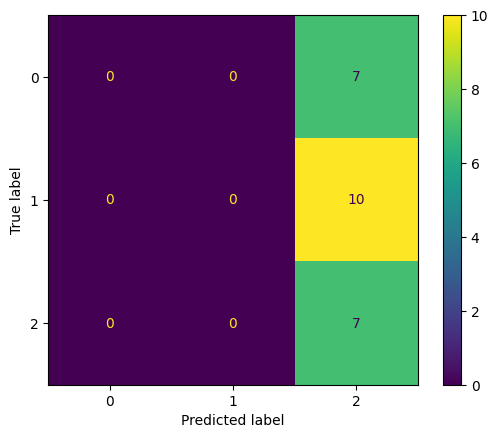

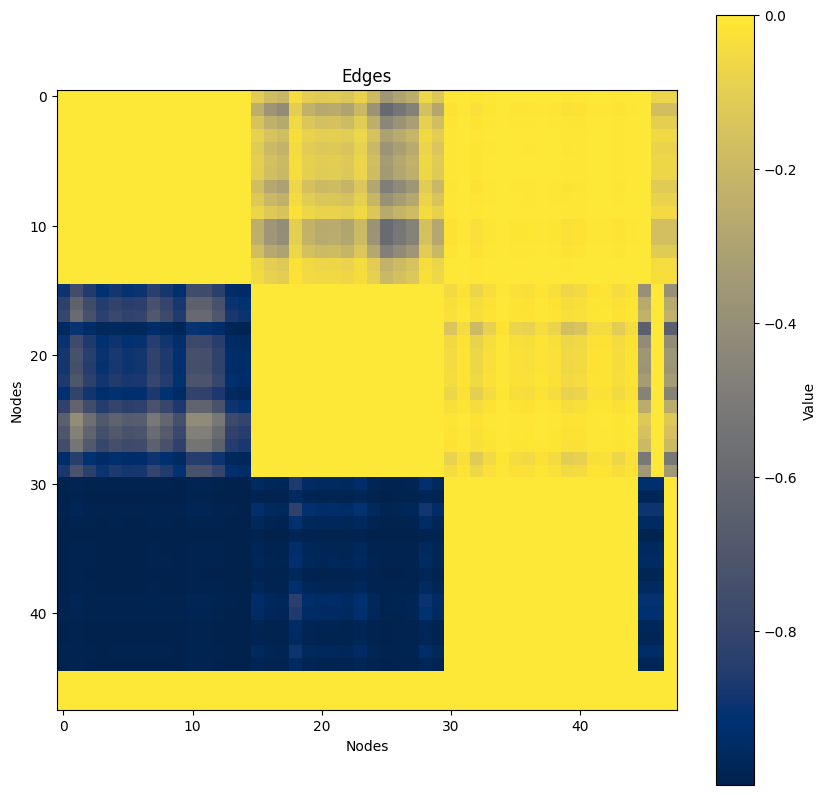

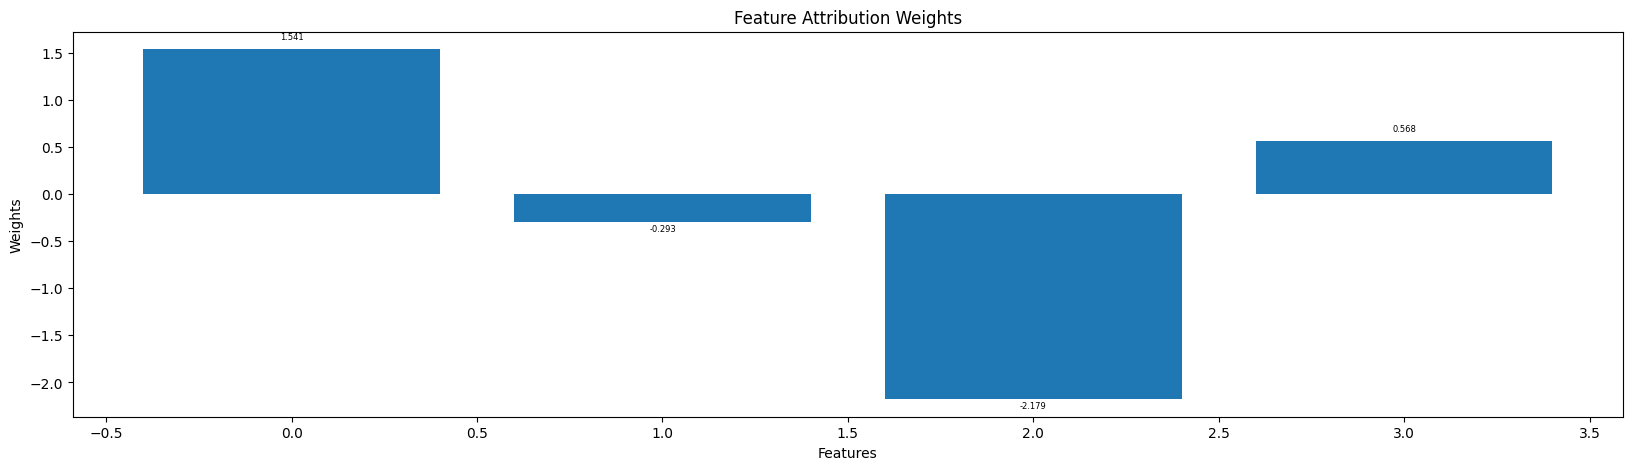

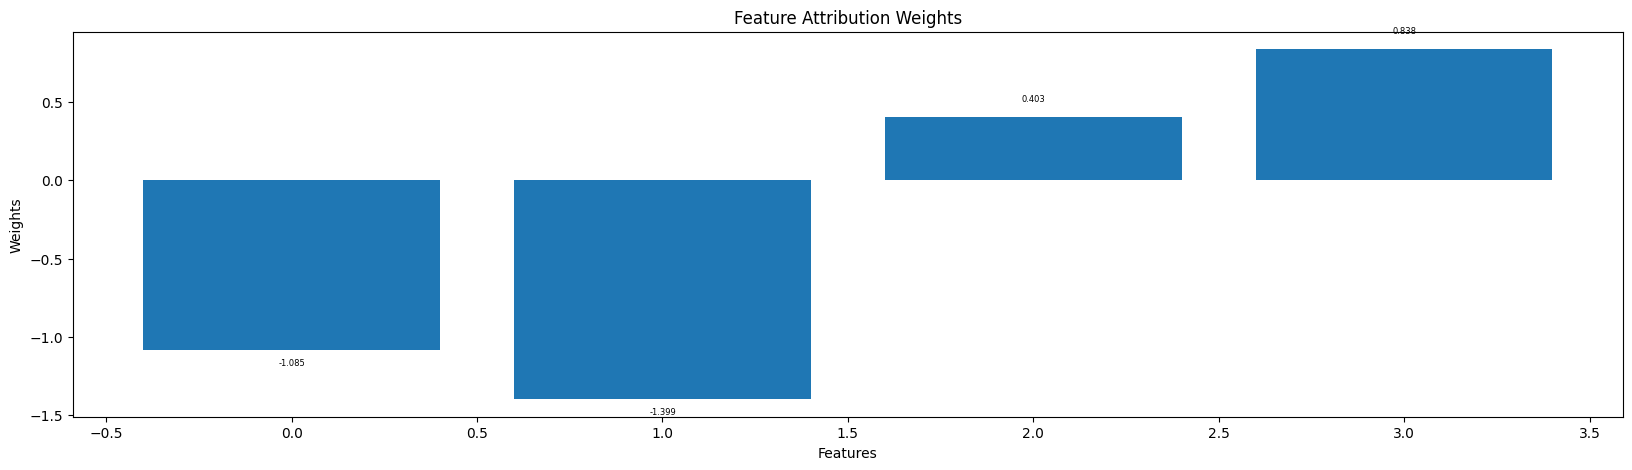

In [61]:
reload_imports()
evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )
# show(model.A.detach().numpy())
model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [62]:

DISABLE_TQDM = False

Epoch 200, Loss: 0.0103: 100%|██████████| 200/200 [00:00<00:00, 216.54it/s]


Gradients:
Function: compute_base_scores.W | Gradients: tensor([ 0.0021,  0.0020, -0.0096, -0.0080])
Function: casebase_edge_weights.W | Gradients: tensor([0.0020, 0.0024, 0.0028, 0.0025])
Finished Training


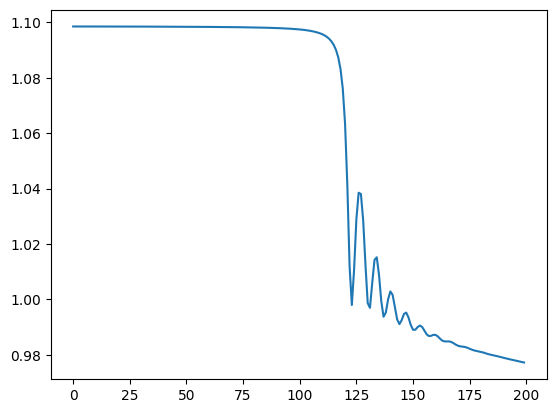

In [63]:
reload_imports()
losses = []
pbar = tqdm(range(EPOCHS), disable=DISABLE_TQDM)

for epoch in pbar:  

        new_cases = X_train
        new_cases_labels = y_train


        optimizer.zero_grad()

        # TODO: consider efficiency issues with having to rebuild each time 
        # Find a way to accumulate gradients update only when necessary?
        model.fit_no_blockers(PREPROCESS_FUNC(X_centroids), y_centroids, X_DEFAULTS, Y_DEFAULTS, USE_SYMMETRIC_ATTACKS)
        # model.fit(PREPROCESS_FUNC(X_centroids), y_centroids, X_DEFAULTS, Y_DEFAULTS, USE_SYMMETRIC_ATTACKS)

        predictions = model(PREPROCESS_FUNC(new_cases)).squeeze()
        loss = criterion(predictions, new_cases_labels)
        # print(f"EPOCH: {epoch}, LOSS: {loss}")

        # if fold == 4 and epoch == (EPOCHS - 1):
        if epoch == (EPOCHS - 1):
            loss.backward(retain_graph=True)
        else:
            loss.backward()

        optimizer.step()
        # Print gradients

        losses.append(loss.item())


        pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(loss.item()/len(new_cases), 4)}')



print("Gradients:")
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"Function: {name} | Gradients: {param.grad}")
    else:
        print(f"Function: {name} | No gradients computed")

# loss = criterion(predictions, new_cases_labels)
# make_dot(loss, show_saved=True, show_attrs=True, params=dict(model.named_parameters())).render("gradual_aacbr_trained", format="pdf")


print('Finished Training')

plt.plot(losses)
plt.show()


/home/adam/Documents/dev/gradual-aacbr/gradual-aacbr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy, Precision, Recall, F1
[0.5833333333333334, 0.4705882352941176, 0.6666666666666666, 0.5277777777777778]


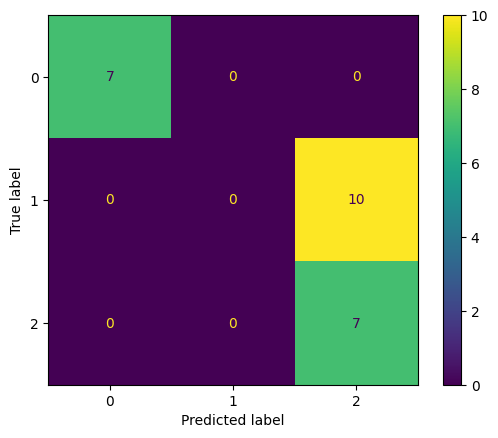

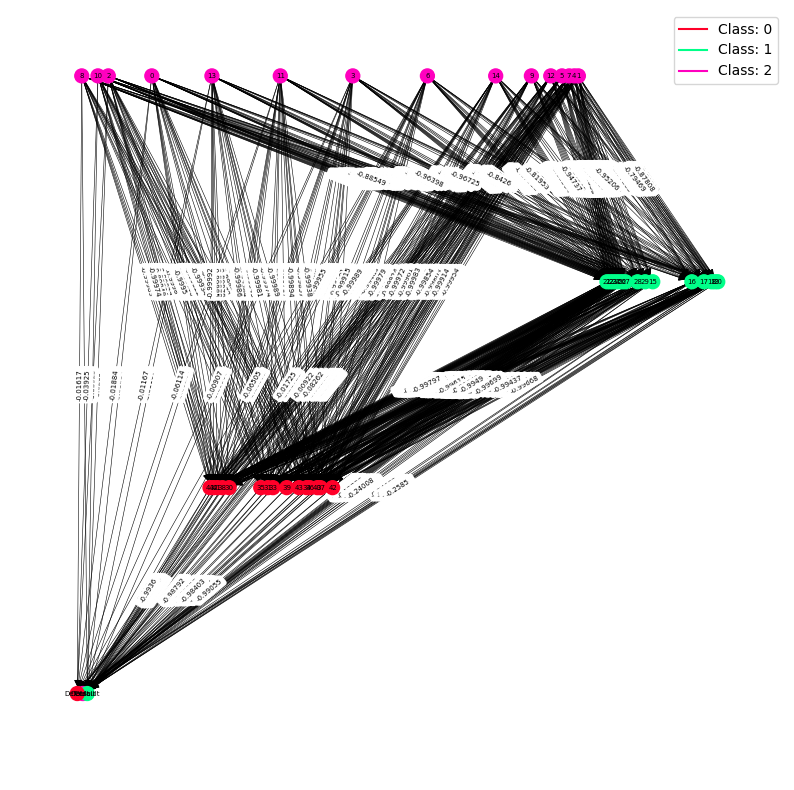

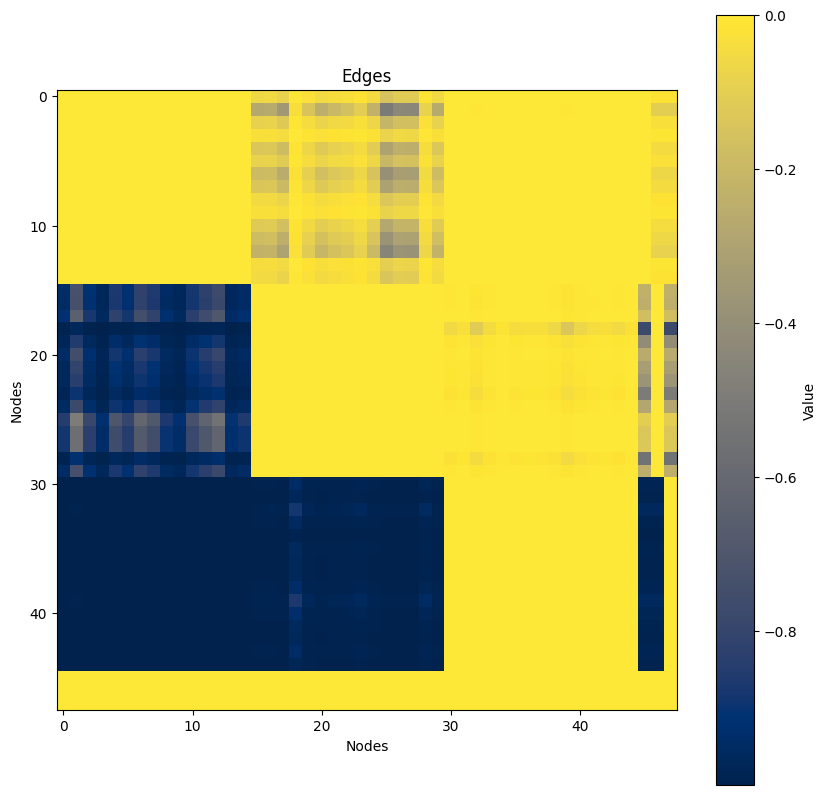

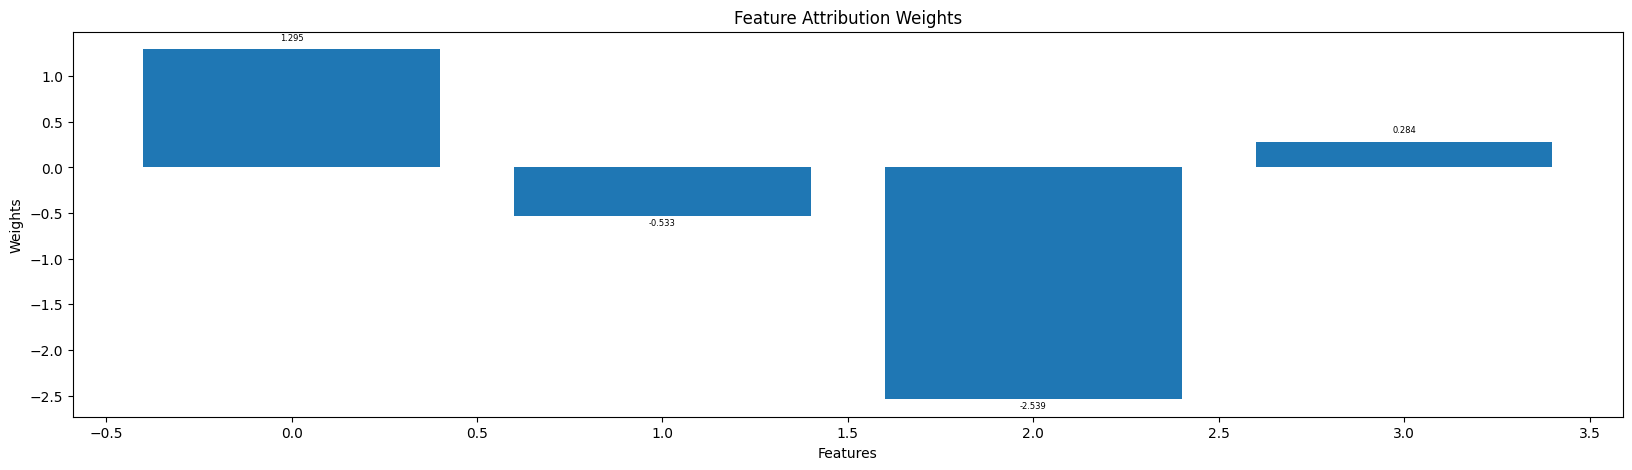

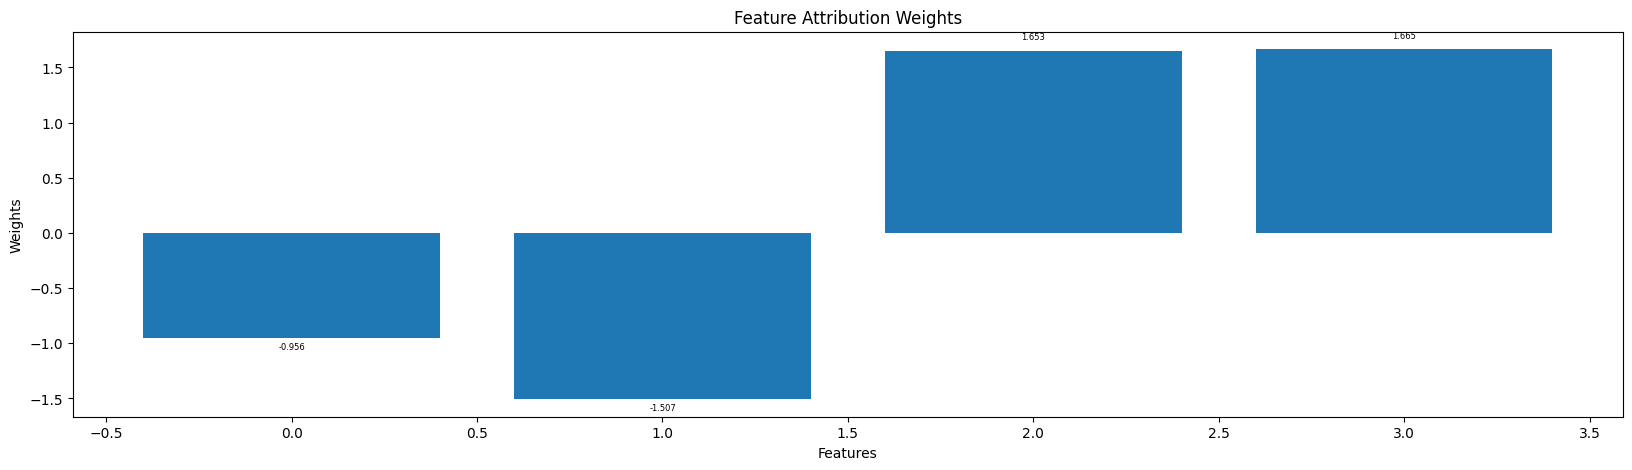

In [64]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=False, print_graph=True  )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

### Test Set

Accuracy, Precision, Recall, F1
[0.7, 0.5166666666666667, 0.6666666666666666, 0.5698924731182796]


/home/adam/Documents/dev/gradual-aacbr/gradual-aacbr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


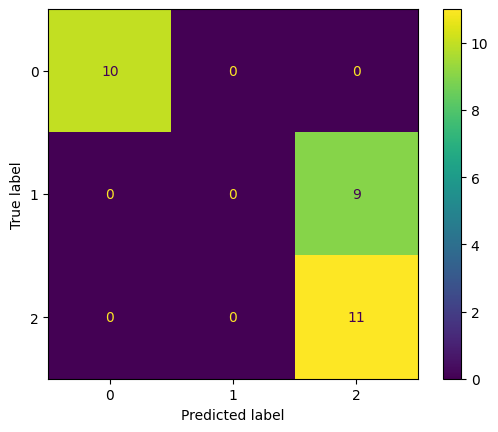

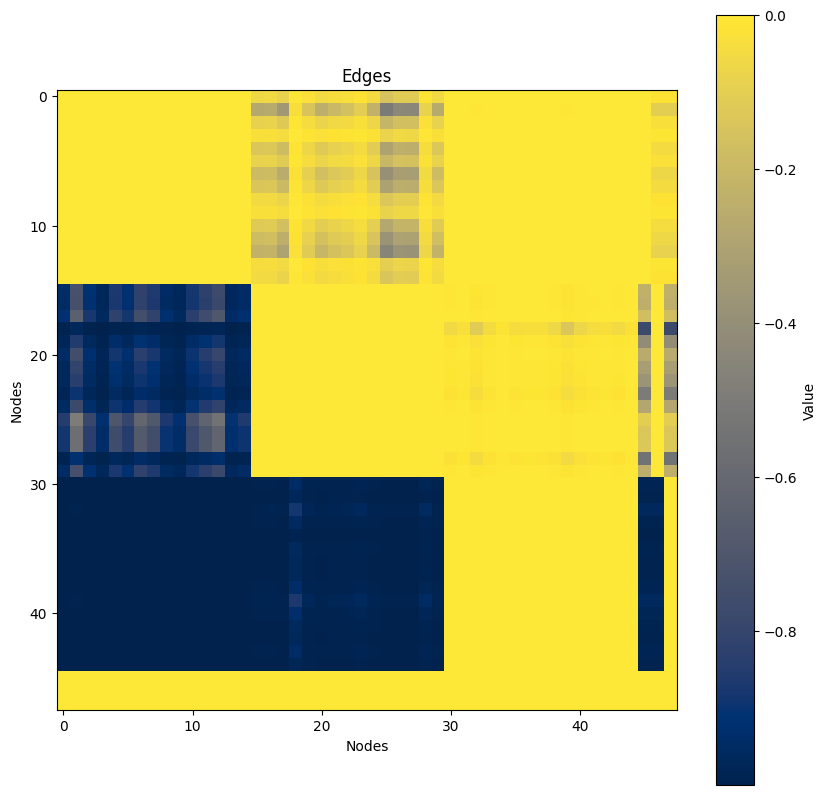

In [65]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_train_full, y_train_full, X_DEFAULTS, Y_DEFAULTS, X_test, y_test, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )